In [1]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
import seaborn as sns
import sys
sys.path.append("..")
from basicfunc import MouseAnatomyTree


In [2]:
homo_color_lut = {
                 'FL':np.array([255,206,72])/255.0,
                 'PL':np.array([153,217,234])/255.0,
                 'TL':np.array([118,137,211])/255.0}

c_mouse = np.array([29/255,140/255,67/255])
c_human = np.array([255,102,102])/255.0

In [3]:
den_type = 'apical'
magnify = False
pyr23_only = False

In [ ]:
mouse_anatomy_tree = MouseAnatomyTree('../Data/external/tree.json')

# cell type
df_ct_mouse = pd.read_csv(r'..\Data\metadata\mouse_celltype.csv',index_col=0)
if pyr23_only:
    df_ct_mouse = df_ct_mouse[df_ct_mouse['layer'].isin(['2/3'])]
    df_ct_mouse = df_ct_mouse[df_ct_mouse['is_pyramidal']==1]
else:
    df_ct_mouse = df_ct_mouse[df_ct_mouse['layer'].isin(['2/3', '5'])]
    df_ct_mouse = df_ct_mouse[df_ct_mouse['is_pyramidal']==1]
    
    pass

df_ct_human = pd.read_csv(r'..\Data\metadata\human_celltype.csv',index_col=0)
if pyr23_only:
    df_ct_human = df_ct_human[df_ct_human['layer'].isin(['L2/3'])]
    df_ct_human = df_ct_human[df_ct_human['is_pyramidal']==1]
else:
    df_ct_human = df_ct_human[df_ct_human['is_pyramidal']==1]
    pass


In [5]:

mouse_feature_dirname = None
human_feature_dirname = None

if den_type == 'apical':
    if magnify:
        mouse_feature_dirname = 'magnify_crop10000_apical'
        human_feature_dirname = 'original_apical'
    else:
        mouse_feature_dirname = 'original_apical'
        human_feature_dirname = 'original_apical'
elif den_type == 'basal':
    if magnify:
        mouse_feature_dirname = 'magnify_crop10000_basal'
        human_feature_dirname = 'original_basal'
    else:
        mouse_feature_dirname = 'original_basal'
        human_feature_dirname = 'original_basal'        
        


In [6]:
path = rf'..\Data\branch_info\mouse\{mouse_feature_dirname}'  # magnify_crop10000_basal, magnify_crop10000_apical, original_basal, original_apical
filelist = os.listdir(path) 

df_allbranch_mouse = []

for i in range(len(filelist)):
    filename = filelist[i]
    fp = os.path.join(path,filename)
    if filename.replace('.csv','.swc') not in df_ct_mouse.index: continue
    ct = df_ct_mouse.loc[filename.replace('.csv','.swc'),'homologous']
    tmpdf = pd.read_csv(fp)
    tmpdf['homologous'] = ct
    tmpdf['CellType'] = df_ct_mouse.loc[filename.replace('.csv','.swc'),'nolayer']
    tmpdf['name'] = filename.replace('.csv','.swc')
    df_allbranch_mouse.extend(tmpdf.to_numpy(dtype='object').tolist())
    
df_allbranch_mouse = pd.DataFrame(df_allbranch_mouse, columns=tmpdf.columns)
for col in tmpdf.columns:
    df_allbranch_mouse[col] = df_allbranch_mouse[col].astype(tmpdf[col].dtype)

In [7]:
path = rf'..\Data\branch_info\human\{human_feature_dirname}'  # original_apical, original_basal
filelist = os.listdir(path)

df_allbranch_human = []

for i in range(len(filelist)):
    filename = filelist[i]
    fp = os.path.join(path,filename)
    if filename.replace('.csv','.swc') not in df_ct_human.index: continue
    ct = df_ct_human.loc[filename.replace('.csv','.swc'),'homologous']
    tmpdf = pd.read_csv(fp)
    tmpdf['homologous'] = ct
    tmpdf['CellType'] = df_ct_human.loc[filename.replace('.csv','.swc'),'CellType']
    tmpdf['name'] = filename.replace('.csv','.swc')
    df_allbranch_human.extend(tmpdf.to_numpy(dtype='object').tolist())
    
df_allbranch_human = pd.DataFrame(df_allbranch_human, columns=tmpdf.columns)
for col in tmpdf.columns:
    df_allbranch_human[col] = df_allbranch_human[col].astype(tmpdf[col].dtype)

In [8]:
df_allbranch_human['plane_deviation_angle'] = 90-df_allbranch_human['plane_deviation_angle']
df_allbranch_mouse['plane_deviation_angle'] = 90-df_allbranch_mouse['plane_deviation_angle']

df_allbranch_human['species'] = 'human'
df_allbranch_mouse['species'] = 'mouse'

In [9]:
multi_branch_mouse = []
multi_branch_ct_mouse = []
multi_branch_numlut_mouse = []


cols = list(df_allbranch_mouse.columns)

id_col = cols.index('id')
pid_col = cols.index('pid')
sister_col = cols.index('sister_id')
level_col = cols.index('branch_level')

# keep np.unique(name) order
names = np.unique(df_allbranch_mouse['name'].to_numpy())

# avoid filtering df_allbranch_mouse[df_allbranch_mouse['name'] == name] each time
group_lut = {
    name: g
    for name, g in df_allbranch_mouse.groupby('name', sort=False)
}

ct_lut = df_ct_mouse['homologous'].to_dict()

for name in names:
    ct = ct_lut[name]
    tmpdf = group_lut[name]

    values = tmpdf.to_numpy(dtype='object', copy=False)

    ids = values[:, id_col]
    pids = values[:, pid_col]
    sister_ids = values[:, sister_col]
    levels = values[:, level_col]

    id_to_pos = {v: i for i, v in enumerate(ids)}

    candidate_mask = (levels <= 5) & (pids != -1)
    candidate_ids = ids[candidate_mask]

    flagged = set()

    for ind in candidate_ids:
        if ind in flagged:
            continue

        pos = id_to_pos[ind]
        sister_id = sister_ids[pos]

        flagged.add(ind)
        flagged.add(sister_id)

        tmp_multi_branch = [
            values[pos],
            values[id_to_pos[sister_id]],
        ]

        pid = pids[pos]

        while pid != -1:
            ppos = id_to_pos[pid]
            tmp_multi_branch.append(values[ppos])
            pid = pids[ppos]

        tmp_multi_branch = np.array(tmp_multi_branch[::-1], dtype='object')

        multi_branch_mouse.append(tmp_multi_branch)
        multi_branch_ct_mouse.append(ct)
        multi_branch_numlut_mouse.append(len(tmp_multi_branch) - 1)

multi_branch_mouse = np.array(multi_branch_mouse,dtype='object')
multi_branch_ct_mouse = np.array(multi_branch_ct_mouse,dtype='object')
multi_branch_numlut_mouse = np.array(multi_branch_numlut_mouse,dtype='object')

In [10]:
multi_branch_human = []
multi_branch_ct_human = []
multi_branch_numlut_human = []

cols = list(df_allbranch_human.columns)

id_col = cols.index('id')
pid_col = cols.index('pid')
sister_col = cols.index('sister_id')
level_col = cols.index('branch_level')

# keep np.unique(name) order
names = np.unique(df_allbranch_human['name'].to_numpy())

# avoid filtering df_allbranch_human[df_allbranch_human['name'] == name] each time
group_lut = {
    name: g
    for name, g in df_allbranch_human.groupby('name', sort=False)
}

ct_lut = df_ct_human['homologous'].to_dict()

for name in names:
    ct = ct_lut[name]
    tmpdf = group_lut[name]

    values = tmpdf.to_numpy(dtype='object', copy=False)

    ids = values[:, id_col]
    pids = values[:, pid_col]
    sister_ids = values[:, sister_col]
    levels = values[:, level_col]

    id_to_pos = {v: i for i, v in enumerate(ids)}

    candidate_mask = (levels <= 5) & (pids != -1)
    candidate_ids = ids[candidate_mask]

    flagged = set()

    for ind in candidate_ids:
        if ind in flagged:
            continue

        pos = id_to_pos[ind]
        sister_id = sister_ids[pos]

        flagged.add(ind)
        flagged.add(sister_id)

        tmp_multi_branch = [
            values[pos],
            values[id_to_pos[sister_id]],
        ]

        pid = pids[pos]

        while pid != -1:
            ppos = id_to_pos[pid]
            tmp_multi_branch.append(values[ppos])
            pid = pids[ppos]

        tmp_multi_branch = np.array(tmp_multi_branch[::-1], dtype='object')

        multi_branch_human.append(tmp_multi_branch)
        multi_branch_ct_human.append(ct)
        multi_branch_numlut_human.append(len(tmp_multi_branch) - 1)

multi_branch_human = np.array(multi_branch_human,dtype='object')
multi_branch_ct_human = np.array(multi_branch_ct_human,dtype='object')
multi_branch_numlut_human = np.array(multi_branch_numlut_human,dtype='object')

In [11]:
def generate_brick_df(species, start_b, b_num):

    if species=='mouse':
        multi_branch = multi_branch_mouse
        multi_branch_ct = multi_branch_ct_mouse
        multi_branch_numlut = multi_branch_numlut_mouse
        df_allbranch = df_allbranch_mouse
    elif species=='human':
        multi_branch = multi_branch_human
        multi_branch_ct = multi_branch_ct_human
        multi_branch_numlut = multi_branch_numlut_human
        df_allbranch = df_allbranch_human

    filter_m_b = multi_branch[multi_branch_numlut==(start_b-1+b_num)]
    filter_m_c = multi_branch_ct[multi_branch_numlut==(start_b-1+b_num)]
    df_col_name = df_allbranch.columns
    hash_col_idx_lut = dict(zip(df_col_name,np.arange(0,len(df_col_name))))
    ensemble_feat = []
    new_col_name = []
    for i in range(len(filter_m_b)):
        tmplist = []
        for j in range(start_b-1, len(filter_m_b[i])-1):
            if j==start_b-1 and j<len(filter_m_b[i])-3:
                usecol = ['euclidean_distance', 'path_distance', 'straightness']
                usecol = [hash_col_idx_lut[x] for x in usecol]
                tmplist.extend(filter_m_b[i][j][usecol].tolist())
            elif j==start_b-1 and j<len(filter_m_b[i])-2:
                usecol = ['euclidean_distance', 'path_distance', 'straightness',
                         'plane_deviation_angle', 
                          'end_local_angle', 'end_remote_angle', 'r_l_angle_ratio']
                usecol = [hash_col_idx_lut[x] for x in usecol]
                tmplist.extend(filter_m_b[i][j][usecol].tolist())
            elif j<len(filter_m_b[i])-2:
                usecol = ['euclidean_distance', 'path_distance', 'straightness',
                         'deviation_angle', 'plane_deviation_angle', 
                          'end_local_angle', 'end_remote_angle', 'r_l_angle_ratio']
                usecol = [hash_col_idx_lut[x] for x in usecol]
                tmplist.extend(filter_m_b[i][j][usecol].tolist())
            else:
                usecol = ['euclidean_distance', 'path_distance', 'straightness',
                         'deviation_angle']
                usecol = [hash_col_idx_lut[x] for x in usecol]

                tmplist.extend([1-int(np.any(filter_m_b[i][j:j+2][:, hash_col_idx_lut['is_terminal']]))])
                
                tmplist.extend(filter_m_b[i][j][usecol].tolist())
                tmplist.extend(filter_m_b[i][j+1][usecol].tolist())

                tmplist.extend(filter_m_b[i][j:j+2][:,usecol].max(axis=0).tolist())
                tmplist.extend(filter_m_b[i][j:j+2][:,usecol].min(axis=0).tolist())
                tmplist.extend(filter_m_b[i][j:j+2][:,usecol].sum(axis=0).tolist())
                tmplist.extend(np.abs(filter_m_b[i][j][usecol]-filter_m_b[i][j+1][usecol]).tolist())
                
                
                
            if i==0:
                if j<len(filter_m_b[i])-2:
                    new_col_name.extend([f'{j+1}_'+x for x in df_col_name[usecol]])
                else:
                    new_col_name.extend(['both_non_terminal'])
                    new_col_name.extend(['1st_ch_'+x for x in df_col_name[usecol]])
                    new_col_name.extend(['2nd_ch_'+x for x in df_col_name[usecol]])
                    new_col_name.extend(['max_ch_'+x for x in df_col_name[usecol]])
                    new_col_name.extend(['min_ch_'+x for x in df_col_name[usecol]])
                    new_col_name.extend(['sum_ch_'+x for x in df_col_name[usecol]])
                    new_col_name.extend(['absdiff_ch_'+x for x in df_col_name[usecol]])

        tmplist += [filter_m_b[i][0][-4]]  # name
        tmplist += [filter_m_b[i][0][-3]]  # homo rgn
        tmplist += [filter_m_b[i][0][-2]]  # cell type
                
        ensemble_feat.append(tmplist)
        
    multi_branch_df = pd.DataFrame(ensemble_feat,columns=new_col_name+['name','homologous','CellType'])

    return multi_branch_df


# single branch level

## mouse vs human

fn: path_distance
level: 2
level: 3
level: 4
level: 5
fn: deviation_angle
level: 2
level: 3
level: 4
level: 5


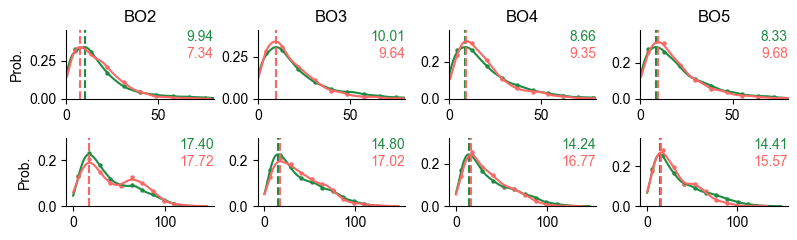

In [12]:
filter_df = pd.concat([df_allbranch_mouse[(df_allbranch_mouse['is_terminal']!=1)&(df_allbranch_mouse['branch_level']<=5)],
                       df_allbranch_human[(df_allbranch_human['is_terminal']!=1)&(df_allbranch_human['branch_level']<=5)]],
                     ignore_index=True)
used_cols = ['path_distance','deviation_angle']
mapped_cols = ['len','d_angle']
sample_size = 1000

fig, axs = plt.subplots(len(used_cols),4,figsize=(8,2.5),tight_layout=True,sharey=None, sharex=None)
fig_tmp, ax_tmp = plt.subplots(1,1)
for i,fn in enumerate(used_cols):
    print('fn:',fn)
    for k,level in enumerate([2,3,4,5]):
        print('level:',level)
        for j,species in enumerate(['mouse','human']):

            ax = axs[i,k]
            tmparr = filter_df[(filter_df['branch_level']==level)&(filter_df['species']==species)][fn].dropna().values
                
            if fn in ['euc_dist_soma_branch_start','deviation_angle','deviation_angle_soma'] and level==1: continue

            if fn=='path_distance': 
                tmparr = tmparr[tmparr<=np.percentile(filter_df[fn],99.5)]
                            
            tmplist = []
            
            tmplist.extend(filter_df[filter_df['branch_level']==level][fn].values.tolist())
            
            counts,bin_edges = np.histogram(tmparr,bins=10,
                                            range=(0,
                                                   np.nanpercentile(filter_df[filter_df['branch_level']==level][fn],99.5)
                                                  ))
            counts = counts/np.sum(counts)
            binwidth=bin_edges[1]-bin_edges[0]
        
            g=sns.kdeplot(x=tmparr, ax=ax_tmp, bw_adjust=1.0, cut=0,
                        clip_on=False, fill=False, 
                        alpha=1, linewidth=0, color=[c_mouse,c_human][j])
            kde_x,kde_y = g.lines[-1].get_data()
            kde_y *= binwidth
            ax.plot(kde_x,kde_y,linewidth=1.5, color=[c_mouse,c_human][j])
            ax.scatter((bin_edges[:-1]+bin_edges[1:])/2,counts,
                       color=[c_mouse,c_human][j],lw=0,marker='.',s=40)
            if j==0: ax.set_ylim(0,np.max(kde_y)*1.15)
            else: ax.set_ylim(0,np.max([np.max(kde_y),ax.get_ylim()[1]])*1.15)
                
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            if k==0: ax.set_ylabel('Prob.')
            else: ax.set_ylabel('')
            if i==0: ax.set_title(f'BO{level}')

            if fn=='straightness': ax.set_xlim(0.8,1)
            if fn in ['euclidean_distance','path_distance']: 
                ax.set_xlim(0,80)
            peak = kde_x[np.argmax(kde_y)]
            ax.axvline(x=peak,color=[c_mouse,c_human][j],ls='--')
            ax.text(1, 1 if species=='mouse' else 0.75, f'{peak:.2f}',fontsize=10,color=[c_mouse,c_human][j],
                    horizontalalignment='right', verticalalignment='top', transform=ax.transAxes)

        
plt.close(fig_tmp)

plt.show(fig)


fn: path_distance
level: 2
level: 3
level: 4
level: 5
fn: deviation_angle
level: 2
level: 3
level: 4
level: 5


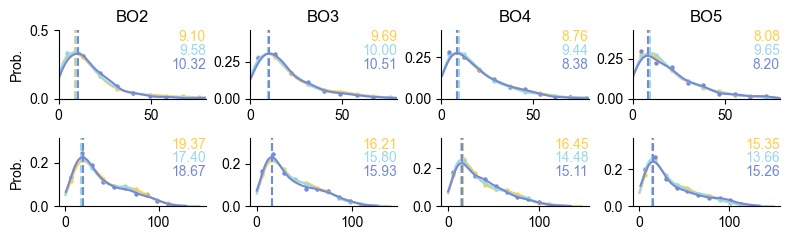

fn: path_distance
level: 2
level: 3
level: 4
level: 5
fn: deviation_angle
level: 2
level: 3
level: 4
level: 5


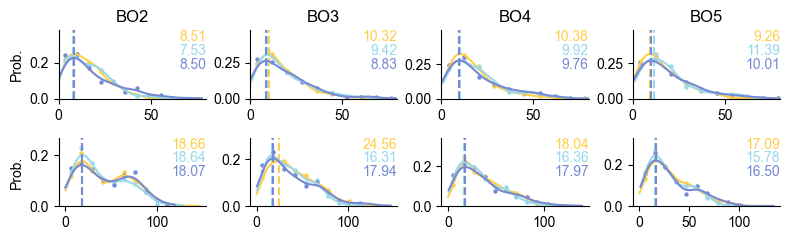

In [13]:
filter_df = pd.concat([df_allbranch_mouse[(df_allbranch_mouse['is_terminal']!=1)&(df_allbranch_mouse['branch_level']<=5)],
                       df_allbranch_human[(df_allbranch_human['is_terminal']!=1)&(df_allbranch_human['branch_level']<=5)]],
                     ignore_index=True)
used_cols = ['path_distance','deviation_angle']
mapped_cols = ['len','d_angle']

for species in ['mouse','human']:
    fig, axs = plt.subplots(len(used_cols),4,figsize=(8,2.5),tight_layout=True,sharey=None, sharex=None)
    fig_tmp, ax_tmp = plt.subplots(1,1)
    for i,fn in enumerate(used_cols):
        print('fn:',fn)
        for k,level in enumerate([2,3,4,5]):
            print('level:',level)
            stat_test_data = [[],[],[]]
            for j,homologous in enumerate(homo_color_lut):
                ax = axs[i,k]
                tmparr = filter_df[(filter_df['branch_level']==level)&(filter_df['species']==species)&(filter_df['homologous']==homologous)][fn].dropna().values
    
                if fn in ['euc_dist_soma_branch_start','deviation_angle','deviation_angle_soma'] and level==1: continue
    
                if fn=='path_distance': 
                    tmparr = tmparr[tmparr<=np.percentile(filter_df[fn],99.5)]
                                
                tmplist = []
                
                tmplist.extend(filter_df[filter_df['branch_level']==level][fn].values.tolist())
                
                counts,bin_edges = np.histogram(tmparr,bins=10,
                                                range=(0,
                                                       np.nanpercentile(filter_df[(filter_df['branch_level']==level)&(filter_df['species']==species)][fn],99.5)
                                                      ))
                counts = counts/np.sum(counts)
                binwidth=bin_edges[1]-bin_edges[0]
            
                g=sns.kdeplot(x=tmparr, ax=ax_tmp, bw_adjust=1.0, cut=0,
                            clip_on=False, fill=False, 
                            alpha=1, linewidth=0, color=list(homo_color_lut.values())[j])
                kde_x,kde_y = g.lines[-1].get_data()
                kde_y *= binwidth
                ax.plot(kde_x,kde_y,linewidth=1.5, color=list(homo_color_lut.values())[j])
                ax.scatter((bin_edges[:-1]+bin_edges[1:])/2,counts,
                           color=list(homo_color_lut.values())[j],lw=0,marker='.',s=40)
                if j==0: ax.set_ylim(0,np.max(kde_y)*1.15)
                else: ax.set_ylim(0,np.max([np.max(kde_y),ax.get_ylim()[1]])*1.15)
                    
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                if k==0: ax.set_ylabel('Prob.')
                else: ax.set_ylabel('')
                if i==0: ax.set_title(f'BO{level}')
    
                if fn=='straightness': ax.set_xlim(0.8,1)
                if fn in ['euclidean_distance','path_distance']: 
                    ax.set_xlim(0,80)
                
                peak = kde_x[np.argmax(kde_y)]
                ax.axvline(x=peak,color=list(homo_color_lut.values())[j],ls='--')
                ax.text(1, 1-0.2*j, f'{peak:.2f}',fontsize=10,color=list(homo_color_lut.values())[j],
                        horizontalalignment='right', verticalalignment='top', transform=ax.transAxes)
              

    plt.close(fig_tmp)

    plt.show(fig)


In [14]:
filter_df = pd.concat([df_allbranch_mouse[(df_allbranch_mouse['is_terminal']!=1)&(df_allbranch_mouse['branch_level']<=5)],
                       df_allbranch_human[(df_allbranch_human['is_terminal']!=1)&(df_allbranch_human['branch_level']<=5)]],
                     ignore_index=True)
used_cols = ['path_distance']
mapped_cols = ['interval']

df_sourcedata = pd.DataFrame(columns=['value','species','homologous','branch_order','feature'])

for i,fn in enumerate(used_cols):
    for k,level in enumerate([2,3,4,5]):
        for j,species in enumerate(['mouse','human']):
            for homologous in homo_color_lut:
                tmparr = filter_df[(filter_df['branch_level']==level)&(filter_df['species']==species)&(filter_df['homologous']==homologous)][fn].dropna().values

                if fn=='path_distance':
                    tmparr = tmparr[tmparr<=np.percentile(filter_df[fn],99.5)]

                df_sourcedata = pd.concat([df_sourcedata,
                                           pd.DataFrame({'value': tmparr,
                                                         'species': species,
                                                         'homologous': homologous,
                                                         'branch_order': f'{level}',
                                                         'feature': mapped_cols[i]})],
                                          ignore_index=True)


# df_sourcedata.to_csv(rf'..\Tables\source_data\{den_type}_interval{"_magnify" if magnify else ""}{"_pyr23" if pyr23_only else ""}.csv', index=False)


# twin branch level

In [15]:
def mykdeplot(data, ax, color, show_peak=False):
    counts,bin_edges = np.histogram(data,bins=10,)
    counts = counts/np.sum(counts)
    binwidth=bin_edges[1]-bin_edges[0]
    
    fig_tmp, ax_tmp = plt.subplots(1,1)
    g=sns.kdeplot(x=data, ax=ax_tmp, bw_adjust=1.0, cut=0,
                clip_on=False, fill=False, 
                alpha=1, linewidth=0, color=color)
    kde_x,kde_y = g.lines[-1].get_data()
    plt.close(fig_tmp)
    
    kde_y *= binwidth
    ax.plot(kde_x,kde_y,linewidth=1.5, color=color)
    ax.scatter((bin_edges[:-1]+bin_edges[1:])/2,counts,
               color=color,lw=0,marker='.',s=40)
    if j==0: ax.set_ylim(0,np.max(kde_y)*1.15)
    else: ax.set_ylim(0,np.max([np.max(kde_y),ax.get_ylim()[1]])*1.15)
        
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if k==0: ax.set_ylabel('Prob.')
    else: ax.set_ylabel('')
    if show_peak:
        peak = kde_x[np.argmax(kde_y)]
        ax.axvline(x=peak,color=color,ls='--')
        textbias = len(ax.texts)
        ax.text(1, 1-textbias*0.2, f'{peak:.2f}',fontsize=10,color=color,
                horizontalalignment='right', verticalalignment='top', transform=ax.transAxes)
    return ax

d:\anaconda3\envs\py38\lib\site-packages\numpy\core\_methods.py:41: RuntimeWarning: invalid value encountered in reduce
  return umr_maximum(a, axis, None, out, keepdims, initial, where)
d:\anaconda3\envs\py38\lib\site-packages\numpy\core\_methods.py:45: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)


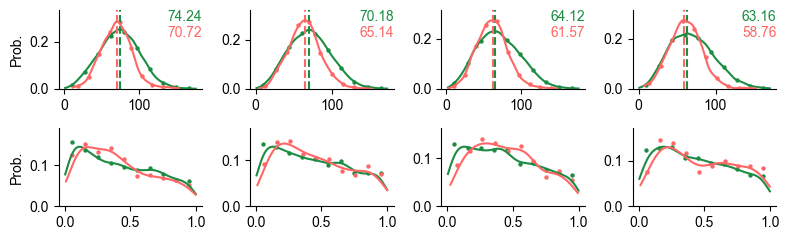

In [16]:
used_cols1 = ['end_remote_angle']
used_cols2 = ['len_symmetry']
mapped_cols = ['alpha_remote','len_symmetry']
levels = [2,3,4,5]
fig, axs = plt.subplots(len(used_cols1)+len(used_cols2),len(levels),figsize=(8,2.5),tight_layout=True,sharey=None, sharex=None)
for i,fn in enumerate(used_cols1+used_cols2):
    for k,level in enumerate(levels):
        for j,species in enumerate(['mouse','human']):
            ax = axs[i,k]
            if fn in used_cols1:
                filter_df = pd.concat([df_allbranch_mouse[(df_allbranch_mouse['is_terminal']!=1)&(df_allbranch_mouse['branch_level']==level)],
                           df_allbranch_human[(df_allbranch_human['is_terminal']!=1)&(df_allbranch_human['branch_level']==level)]],
                         ignore_index=True)
                tmparr = filter_df[(filter_df['species']==species)][fn].dropna().values
            else:
                multi_branch_df = generate_brick_df(species,level-1,2)
                multi_branch_df = multi_branch_df[multi_branch_df['both_non_terminal']==1]
                multi_branch_df['len_symmetry'] = multi_branch_df['min_ch_path_distance'] / multi_branch_df['max_ch_path_distance']
                multi_branch_df['angle_symmetry'] = multi_branch_df['min_ch_deviation_angle'] / multi_branch_df['max_ch_deviation_angle']
                tmparr = multi_branch_df[fn].dropna().values
            
            color = [c_mouse,c_human][j]
            
            mykdeplot(tmparr,ax=ax,color=color,show_peak=True if fn!='len_symmetry' else False)

plt.show(fig)


d:\anaconda3\envs\py38\lib\site-packages\numpy\core\_methods.py:41: RuntimeWarning: invalid value encountered in reduce
  return umr_maximum(a, axis, None, out, keepdims, initial, where)
d:\anaconda3\envs\py38\lib\site-packages\numpy\core\_methods.py:45: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)
d:\anaconda3\envs\py38\lib\site-packages\numpy\core\_methods.py:41: RuntimeWarning: invalid value encountered in reduce
  return umr_maximum(a, axis, None, out, keepdims, initial, where)
d:\anaconda3\envs\py38\lib\site-packages\numpy\core\_methods.py:45: RuntimeWarning: invalid value encountered in reduce
  return umr_minimum(a, axis, None, out, keepdims, initial, where)
d:\anaconda3\envs\py38\lib\site-packages\numpy\core\_methods.py:41: RuntimeWarning: invalid value encountered in reduce
  return umr_maximum(a, axis, None, out, keepdims, initial, where)
d:\anaconda3\envs\py38\lib\site-packages\numpy\core\_methods.py:4

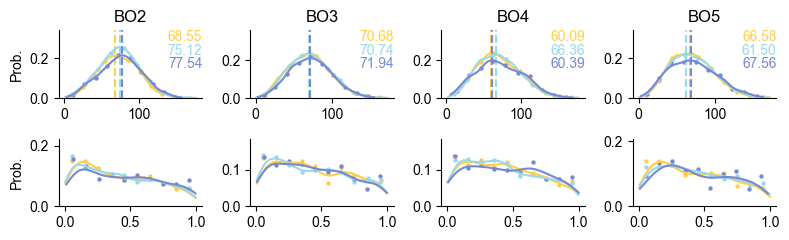

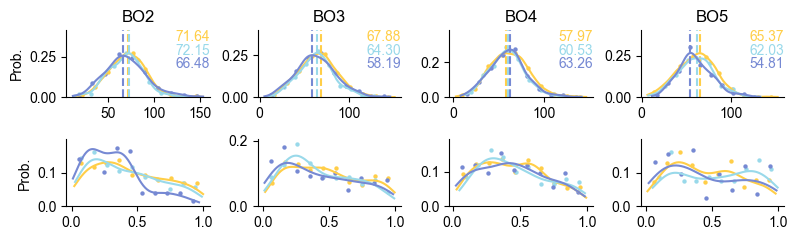

In [17]:
used_cols1 = ['end_remote_angle']
used_cols2 = ['len_symmetry']
mapped_cols = ['alpha_remote','len_symmetry']
levels = [2,3,4,5]
for species in ['mouse','human']:
    fig, axs = plt.subplots(len(used_cols1)+len(used_cols2),len(levels),figsize=(8,2.5),tight_layout=True,sharey=None, sharex=None)
    for i,fn in enumerate(used_cols1+used_cols2):
        for k,level in enumerate(levels):
            stat_test_data = [[],[],[]]
            for j,homologous in enumerate(['FL','PL','TL']):
                ax = axs[i,k]
                if fn in used_cols1:
                    if species=='mouse':
                        filter_df = df_allbranch_mouse[(df_allbranch_mouse['is_terminal']!=1)&(df_allbranch_mouse['branch_level']==level)]
                    elif species=='human':
                        filter_df = df_allbranch_human[(df_allbranch_human['is_terminal']!=1)&(df_allbranch_human['branch_level']==level)]
                    tmparr = filter_df[(filter_df['homologous']==homologous)][fn].dropna().values
                else:
                    multi_branch_df = generate_brick_df(species,level-1,2)
                    multi_branch_df = multi_branch_df[multi_branch_df['both_non_terminal']==1]
                    multi_branch_df['len_symmetry'] = multi_branch_df['min_ch_path_distance'] / multi_branch_df['max_ch_path_distance']
                    multi_branch_df['angle_symmetry'] = multi_branch_df['min_ch_deviation_angle'] / multi_branch_df['max_ch_deviation_angle']
                    tmparr = multi_branch_df[multi_branch_df['homologous']==homologous][fn].dropna().values
    
                color=homo_color_lut[homologous]
                
                mykdeplot(tmparr,ax=ax,color=color,show_peak=True if fn!='len_symmetry' else False)
                
                stat_test_data[j] = tmparr
                if k==0: ax.set_ylabel('Prob.')
                if i==0: ax.set_title(f'BO{level}')
      

    plt.show(fig)


In [18]:
used_cols1 = ['end_remote_angle']
mapped_cols = ['angle']
levels = [2,3,4,5]

df_sourcedata = pd.DataFrame(columns=['value','species','homologous','branch_order','feature'])

for i,fn in enumerate(used_cols1):
    for k,level in enumerate(levels):
        for species in ['mouse','human']:
            for homologous in ['FL','PL','TL']:
                if fn in used_cols1:
                    if species=='mouse':
                        filter_df = df_allbranch_mouse[(df_allbranch_mouse['is_terminal']!=1)&(df_allbranch_mouse['branch_level']==level)]
                    elif species=='human':
                        filter_df = df_allbranch_human[(df_allbranch_human['is_terminal']!=1)&(df_allbranch_human['branch_level']==level)]
                    tmparr = filter_df[(filter_df['homologous']==homologous)][fn].dropna().values

                df_sourcedata = pd.concat([df_sourcedata,
                                           pd.DataFrame({'value': tmparr,
                                                         'species': species,
                                                         'homologous': homologous,
                                                         'branch_order': f'{level}',
                                                         'feature': mapped_cols[i]})],
                                          ignore_index=True)

# df_sourcedata.to_csv(rf'..\Tables\source_data\{den_type}_angle{"_pyr23" if pyr23_only else ""}.csv', index=False)
